Enter number of arms: 5
Enter number of episodes: 1000
Enter learning rate: 0.1

Actual Reward Probabilities of Arms:
[0.50113135 0.48998814 0.31158539 0.54269157 0.37165032]

Learned Preferences by Agent:
[-2.6830766 -4.749876  -2.4114044  4.58081   -2.2404213]

Best Arm According to Environment:
3

Best Arm Learned by Agent:
3

Total Reward Earned:
519


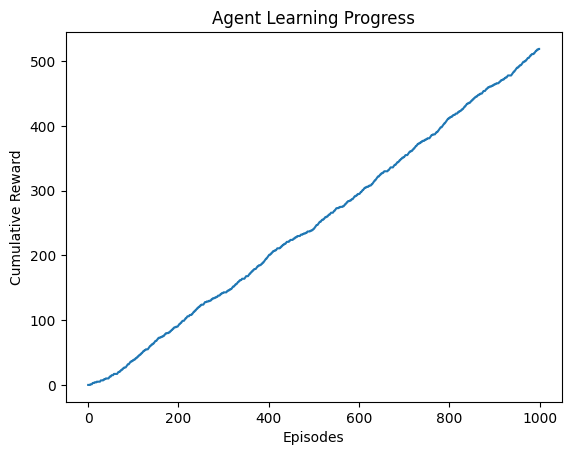

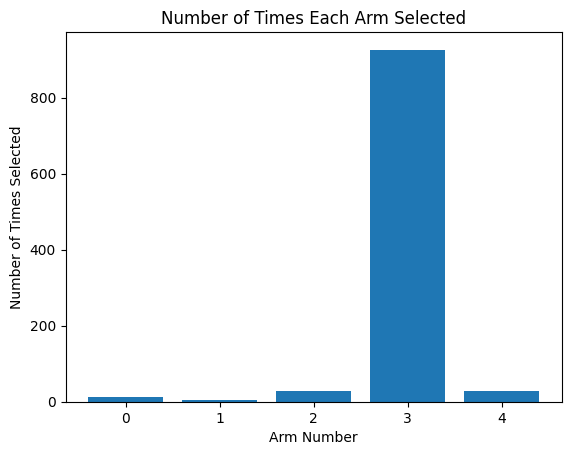

In [2]:
# Project: Multi-Armed Bandit Problem using Python and TensorFlow

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Take User Input
# -------------------------------

arms = int(input("Enter number of arms: "))
episodes = int(input("Enter number of episodes: "))
learning_rate = float(input("Enter learning rate: "))


# -------------------------------
# Step 2: Create Environment
# -------------------------------

class MultiArmedBandit:
    def __init__(self, arms):
        self.arms = arms
        self.reward_probs = np.random.rand(arms)

    def get_reward(self, action):
        random_value = np.random.rand()

        if random_value < self.reward_probs[action]:
            return 1
        else:
            return 0


# -------------------------------
# Step 3: Create Agent
# -------------------------------

class BanditAgent:
    def __init__(self, arms, learning_rate):
        self.arms = arms

        self.preferences = tf.Variable(
            tf.zeros([arms], dtype=tf.float32)
        )

        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    def choose_action(self):
        probabilities = tf.nn.softmax(self.preferences).numpy()

        action = np.random.choice(
            self.arms,
            p=probabilities
        )

        return action

    def train(self, action, reward):
        with tf.GradientTape() as tape:
            probabilities = tf.nn.softmax(self.preferences)

            log_probability = tf.math.log(probabilities[action])

            loss = -log_probability * reward

        gradients = tape.gradient(loss, [self.preferences])

        self.optimizer.apply_gradients(
            zip(gradients, [self.preferences])
        )


# -------------------------------
# Step 4: Train the Agent
# -------------------------------

environment = MultiArmedBandit(arms)
agent = BanditAgent(arms, learning_rate)

rewards = []
selected_actions = []

for episode in range(episodes):
    action = agent.choose_action()

    reward = environment.get_reward(action)

    agent.train(action, reward)

    rewards.append(reward)
    selected_actions.append(action)


# -------------------------------
# Step 5: Display Results
# -------------------------------

print("\nActual Reward Probabilities of Arms:")
print(environment.reward_probs)

print("\nLearned Preferences by Agent:")
print(agent.preferences.numpy())

print("\nBest Arm According to Environment:")
print(np.argmax(environment.reward_probs))

print("\nBest Arm Learned by Agent:")
print(np.argmax(agent.preferences.numpy()))

print("\nTotal Reward Earned:")
print(sum(rewards))


# -------------------------------
# Step 6: Plot Cumulative Reward
# -------------------------------

plt.plot(np.cumsum(rewards))
plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Agent Learning Progress")
plt.show()


# -------------------------------
# Step 7: Plot Arm Selection Count
# -------------------------------

plt.hist(
    selected_actions,
    bins=np.arange(arms + 1) - 0.5,
    rwidth=0.8
)

plt.xlabel("Arm Number")
plt.ylabel("Number of Times Selected")
plt.title("Number of Times Each Arm Selected")
plt.xticks(range(arms))
plt.show()